# Bulding information

Manually created json

```python
FILENAME: str = "../data/buildings.json"
```

In [5]:
[
   {
      "building_id": 1,
      "name": "Butcher",
      "door_orientation": "South",
      "validation_color": "red",
      "validation_symbol": "square",
      "grid_pos_x": 2,
      "grid_pos_z": 1,
      "world_pos_x": 68.87,
      "world_pos_z": 36.33
   },
   {
      "building_id": 2,
      "name": "Barn",
      "door_orientation": "East",
      "validation_color": "orange",
      "validation_symbol": "circle",
      "grid_pos_x": 5,
      "grid_pos_z": 2,
      "world_pos_x": 162.97,
      "world_pos_z": 74.07
   },
   ...
]

[{'building_id': 1,
  'name': 'Butcher',
  'door_orientation': 'South',
  'validation_color': 'red',
  'validation_symbol': 'square',
  'grid_pos_x': 2,
  'grid_pos_z': 1,
  'world_pos_x': 68.87,
  'world_pos_z': 36.33},
 {'building_id': 2,
  'name': 'Barn',
  'door_orientation': 'East',
  'validation_color': 'orange',
  'validation_symbol': 'circle',
  'grid_pos_x': 5,
  'grid_pos_z': 2,
  'world_pos_x': 162.97,
  'world_pos_z': 74.07},
 Ellipsis]

# Import building data

In [6]:
# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_x_offset = BLOCK_SIZE / 2
map_z_offset = BLOCK_SIZE / 2

map_coord = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top

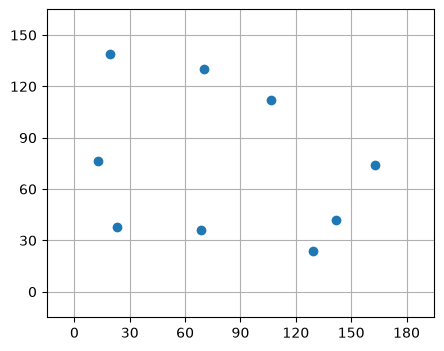

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BUILDING_FILENAME: str = "../data/buildings.json"

buildings_data: pd.DataFrame = pd.read_json(BUILDING_FILENAME).set_index("building_id")

#print(buildings_data)

x = [ pos_x for pos_x in buildings_data["world_pos_x"]]
z = [pos_z for pos_z in buildings_data["world_pos_z"]]

fig, ax = plt.subplots(figsize=(5,4))

scatter = ax.scatter(x, z)

ticks = np.arange(0,map_extent[1],30)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

plt.xlim(map_extent[0],map_extent[1])
plt.ylim(map_extent[2], map_extent[3])

plt.grid()


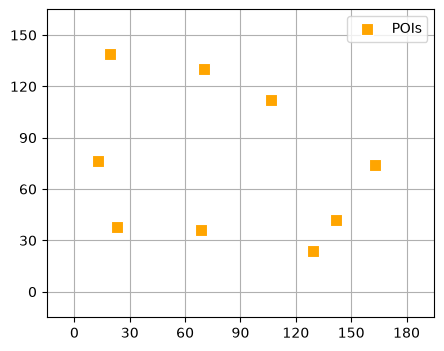

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

BUILDING_FILENAME: str = "../data/buildings.json"

buildings_data: pd.DataFrame = pd.read_json(BUILDING_FILENAME).set_index("building_id")

#print(buildings_data)

x = [ pos_x for pos_x in buildings_data["world_pos_x"]]
z = [pos_z for pos_z in buildings_data["world_pos_z"]]

fig, ax = plt.subplots(figsize=(5,4))


ax.scatter(
    buildings_data["world_pos_x"],
    buildings_data["world_pos_z"],
    marker='s',        # squares to distinguish from player dots
    c='orange',
    s=80,
    edgecolors='white',
    linewidths=0.8,
    zorder=6,
    label='POIs'
)



ax.legend()
ticks = np.arange(0,map_extent[1],30)

ax.set_xticks(ticks)
ax.set_yticks(ticks)

plt.xlim(map_extent[0],map_extent[1])
plt.ylim(map_extent[2], map_extent[3])

plt.grid()
fig.canvas.draw_idle()


## POI Labels
Add labels

In [20]:
for _, row in buildings_data.iterrows():
    ax.annotate(
        row["name"],  # building_id since it's the index
        (row["world_pos_x"], row["world_pos_z"]),
        textcoords="offset points",
        xytext=(6, 6),          # pixel offset from the dot
        fontsize=7,
        color="black",
        zorder=7
    )
